In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
import json

plt.style.use('default')

In [258]:
cnt_points = 21
fpr_range = [0, 0.4]
tpr_range = [0.6, 1]

In [259]:
q = 1.0/5
s = 30

In [260]:
FPR = np.linspace(*fpr_range, num = cnt_points)[:, None] # column vec
TPR = np.linspace(*tpr_range, num = cnt_points)[:, None] # column vec

In [261]:
p_acc = q * (1 - TPR) + (1-q) * (1 - FPR.T) # (TPR, FPR)
p_FO = q * (1 - TPR) / p_acc # (TPR, FPR)

expected_count = (s / p_acc) 

note that: rows-cols = y-x

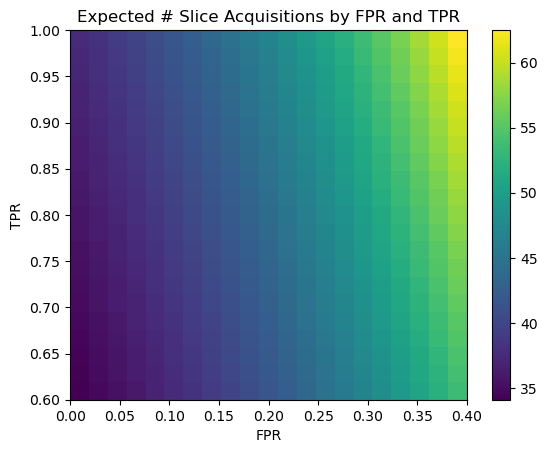

In [262]:
plt.imshow(expected_count, origin='lower', extent=fpr_range + tpr_range,
           aspect='auto') 

plt.colorbar()
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Expected # Slice Acquisitions by FPR and TPR')
plt.savefig('figs/exp_acq')

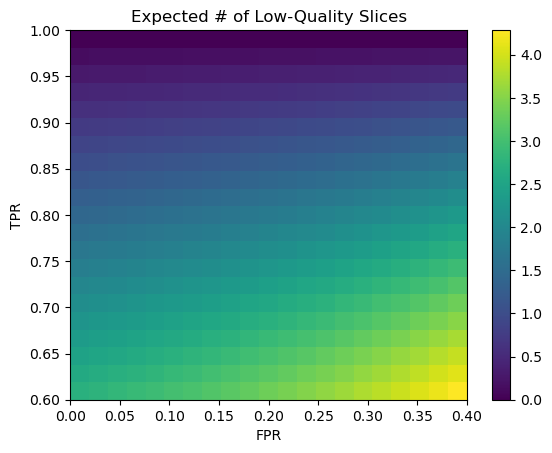

In [263]:
plt.imshow(s * p_FO, origin='lower', extent=fpr_range + tpr_range,
           aspect='auto') 

plt.colorbar()
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Expected # of Low-Quality Slices')
plt.savefig('figs/exp_frac')

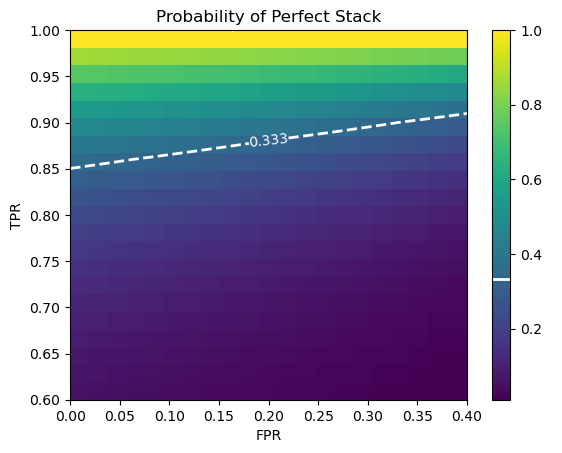

In [264]:
Z = (1 - p_FO)**s

x = np.linspace(fpr_range[0], fpr_range[1], Z.shape[1])
y = np.linspace(tpr_range[0], tpr_range[1], Z.shape[0])

fig, ax = plt.subplots()

im = ax.imshow(
    Z,
    origin='lower',
    extent=[fpr_range[0], fpr_range[1], tpr_range[0], tpr_range[1]],
    aspect='auto'
)

cs = ax.contour(
    x,
    y,
    Z,
    levels=[0.333],
    colors='white',
    linewidths=2,
    linestyles='dashed'
)

ax.clabel(cs, fmt={0.333: "0.333"}, colors='white')
# fig.colorbar(im, ax=ax)  

cbar = fig.colorbar(im, ax=ax)

cbar.ax.hlines(
    0.333,
    *cbar.ax.get_xlim(),
    colors='white',
    linewidth=2
)

cbar.ax.text(
    1.1, 0.333,
    '0.333',
    color='white',
    va='center',
    transform=cbar.ax.get_yaxis_transform()
)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('Probability of Perfect Stack')


fig.savefig('figs/perfect_stack_fpr_tpr.png')

# Plotting the metrics wrt model's thresholds

In [265]:
roc_json_path = Path('../outputs/models/resnet50/run2/test_info/model_auc_ROC.json')

In [266]:
with open(roc_json_path, 'r') as f:
    roc_dict = json.load(f)

fpr, tpr, ts = roc_dict['fpr'], roc_dict['tpr'], roc_dict['ts']
FPR = np.array(fpr)
TPR = np.array(tpr)

In [267]:
p_acc = q * (1 - TPR) + (1-q) * (1 - FPR)
p_FO = q * (1 - TPR) / p_acc 

expected_count = (s / p_acc) 
expected_frac = s * p_FO

var_count = (s * (1 - p_acc)) / (p_acc ** 2)
var_frac = s * p_FO * (1 - p_FO)

/tmp/ipykernel_1041706/714976220.py:2: RuntimeWarning: invalid value encountered in divide
  p_FO = q * (1 - TPR) / p_acc
/tmp/ipykernel_1041706/714976220.py:4: RuntimeWarning: divide by zero encountered in divide
  expected_count = (s / p_acc)
/tmp/ipykernel_1041706/714976220.py:7: RuntimeWarning: divide by zero encountered in divide
  var_count = (s * (1 - p_acc)) / (p_acc ** 2)


In [268]:
expected_count_old = s

expected_frac_old = q * s
var_frac_old = q * (1 - q) * s

In [269]:
std_count = np.sqrt(var_count)
std_frac = np.sqrt(var_frac)
std_frac_old = np.sqrt(var_frac_old)

/tmp/ipykernel_1041706/3184958445.py:7: RuntimeWarning: invalid value encountered in subtract
  expected_count - std_count,


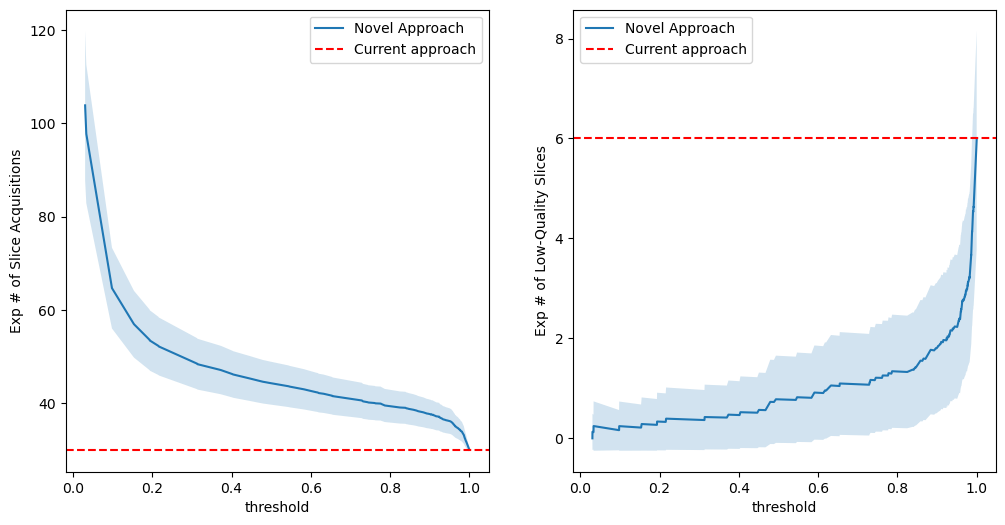

In [270]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# --- Expected count ---
ax[0].plot(ts, expected_count, label="Novel Approach")
ax[0].fill_between(
    ts,
    expected_count - std_count,
    expected_count + std_count,
    alpha=0.2,
)
ax[0].set_xlabel('threshold')
ax[0].set_ylabel('Exp # of Slice Acquisitions')
ax[0].axhline(y=expected_count_old, linestyle='--', label='Current approach', color = 'red')
ax[0].legend()

# --- p_FO ---
ax[1].plot(ts, expected_frac, label="Novel Approach")
ax[1].fill_between(
    ts,
    expected_frac - std_frac,
    expected_frac + std_frac,
    alpha=0.2,
)

ax[1].axhline(y=expected_frac_old, linestyle='--', label='Current approach', color = 'red')
# ax[1].errorbar(
#     ts[len(ts) // 2],
#     expected_frac_old,
#     yerr=std_frac_old,
#     fmt='o',
#     color='red',
#     capsize=5,
# )

ax[1].set_xlabel('threshold')
ax[1].set_ylabel('Exp # of Low-Quality Slices')
ax[1].legend()

fig.savefig('figs/thresh_metrics.png')

Plot the new "ROC" Curve

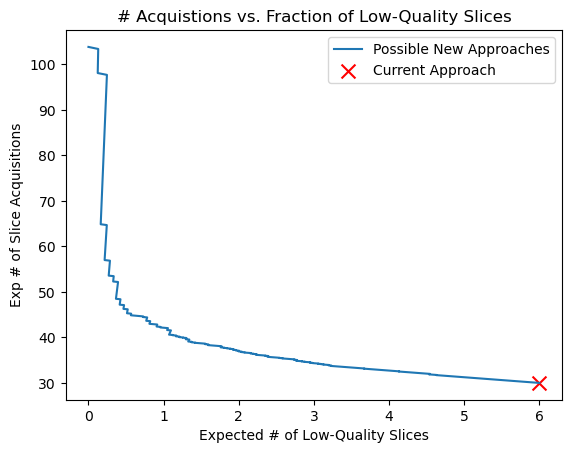

In [271]:
import numpy as np

plt.plot(expected_frac, expected_count, label='Possible New Approaches')
plt.scatter([q * s], [s], s=100, marker='x', color='red', label='Current Approach')

plt.xlabel('Expected # of Low-Quality Slices')
plt.ylabel('Exp # of Slice Acquisitions')
plt.title('# Acquistions vs. Fraction of Low-Quality Slices')

# # 0%, 2.5%, 5%, ..., 20%
# ticks = np.arange(0, 0.2001, 0.025)
# plt.xticks(ticks, [f'{t*100:g}%' for t in ticks])

# plt.xlim(0, 0.22)

plt.legend()
plt.savefig('figs/ROC_new.png')

Probability of Getting Perfect Stack

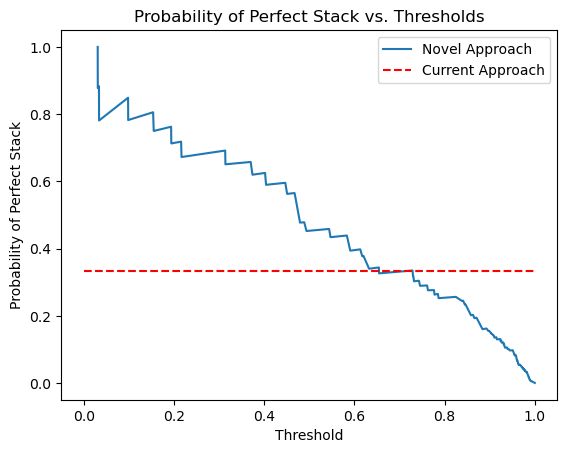

In [272]:
plt.plot(ts, (1 - p_FO) ** s, label = 'Novel Approach')
plt.xlabel("Threshold")
plt.ylabel("Probability of Perfect Stack")
plt.title('Probability of Perfect Stack vs. Thresholds')

plt.hlines(y=0.3333, xmin = 0, xmax = 1, linestyle = '--', label = 'Current Approach', color = 'red')
plt.legend()
plt.savefig('figs/perfect_stack.png')